#### 문제01) 과목별 점수를 세로 막대그래프로 표현하시오 
#### 그래프 제목: "과목별 점수"  
#### x축: 과목 / y축: 점수 
#### 막대 위에 점수 값 표시  
#### python 항목 부분에만 레이블 값이 출력되도록 수정

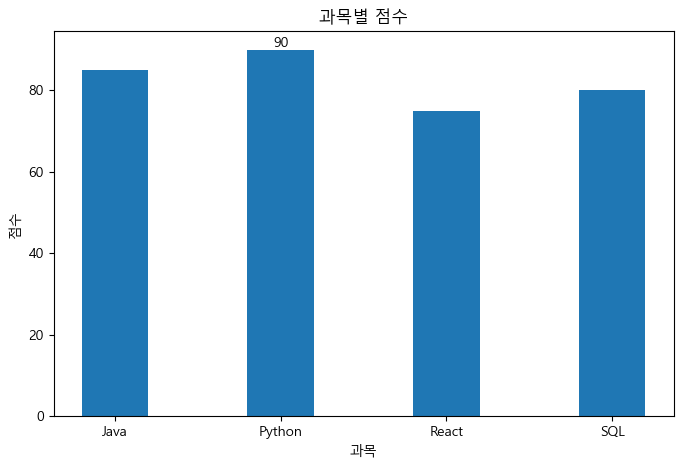

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "과목": ["Java", "Python", "React", "SQL"],
    "점수": [85, 90, 75, 80]
})

# 01. 한글 깨짐 방지 설정★
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 02. 그래프 크기 설정
plt.figure(figsize=(8,5))

# 03. 세로 그래프
bars = plt.bar(df['과목'],df['점수'],width=0.4)

# 04. 차트 제목, 라벨 지정
plt.title('과목별 점수')
plt.xlabel('과목')
plt.ylabel('점수')

# ★ for range(len())
for i in range(len(bars)):
    bar = bars[i] # 예) java의 막대그래프, Python의 막대그래프... 이런식인가?
    height = bar.get_height()
    # python인 경우만 출력
    if df['과목'][i] =='Python': 
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height, str(height), ha = 'center', va= 'bottom')

plt.show()

#### 문제02) 공부시간을 가로 막대그래프로 표현하시오 
#### 막대 두께를 0.5로 설정
#### 그래프 제목: "학생별 공부시간"

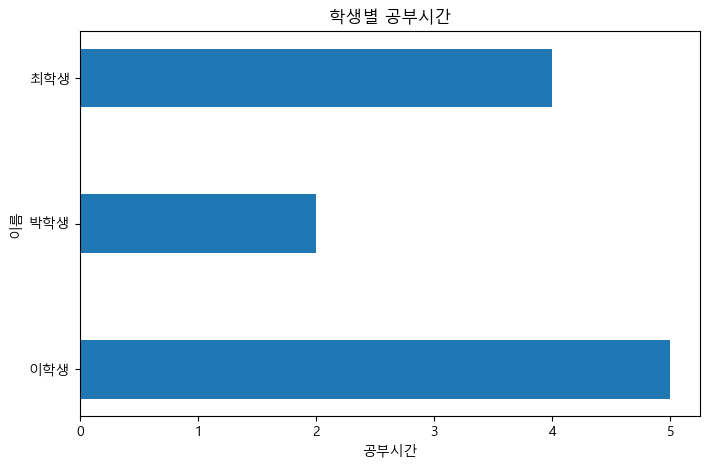

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "이름": ["김학생", "이학생", "박학생", "최학생"],
    "공부시간": [3, 5, 2, 4]
})

# 01. 한글 깨짐 방지 설정★
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 02. 그래프 크기 설정
plt.figure(figsize=(8,5))

# 03. 가로 그래프
df = df[df['이름'] != '김학생']
plt.barh(df['이름'],df['공부시간'],height=0.4)

# 제목, 라벨 지정
plt.title('학생별 공부시간')
plt.xlabel('공부시간')
plt.ylabel('이름')

plt.show()

#### 문제03) 매출 데이터를 선그래프로 표현 
#### marker 추가
#### 선 아래 영역을 색으로 채우기
#### 그래프 제목: "월별 매출 변화"


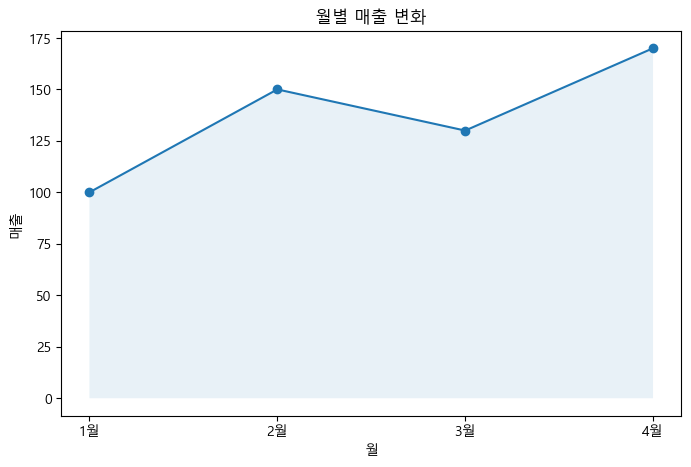

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
# 숫자 계산 쉽게하는 라이브러리 불러오기
import numpy as np
# 데이터 사이를 부드럽게 연결해주는 함수
from scipy.interpolate import make_interp_spline

df = pd.DataFrame({
    "월": ["1월", "2월", "3월", "4월"],
    "매출": [100, 150, 130, 170]
})

# 01. 한글 깨짐 방지 설정★
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 02. 그래프 크기 설정
plt.figure(figsize=(8,5))

# 03. 꺽은선 그래프
plt.plot(df['월'],df['매출'],marker='o')

# 04. 영역 채우기
plt.fill_between(df['월'],df['매출'],alpha=0.1)

# 05. 제목, 라벨 지정
plt.title('월별 매출 변화')
plt.xlabel('월')
plt.ylabel('매출')

# ★ 곡선 그래프에 사용
x = np.arange(len(df['월'])) # x축을 숫자로 변환
y = df['매출']

plt.show()

#### 문제04) 금액을 기준으로 원형 그래프 생성
#### 퍼센트 표시
#### 시작 각도 90도 설정
#### 그래프 제목: "지출 비율“

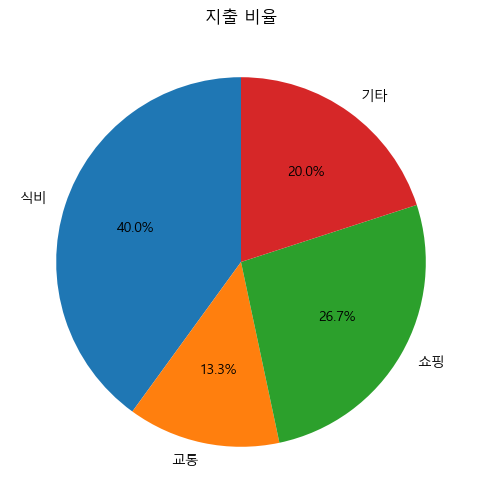

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "카테고리": ["식비", "교통", "쇼핑", "기타"],
    "금액": [300000, 100000, 200000, 150000]
})

# 01. 한글 깨짐 방지 설정★
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 02. 그래프 크기 설정
plt.figure(figsize=(6,6))

# 03. 원형그래프
plt.pie(df['금액'],labels=df['카테고리'], autopct='%1.1f%%', startangle=90)

# 04. 제목, 라벨 지정
plt.title('지출 비율')

plt.show()


#### 문제05) 사용자 비율을 도넛 그래프로 표현
#### 가운데 원 추가
#### 그래프 제목: "OS 점유율" 

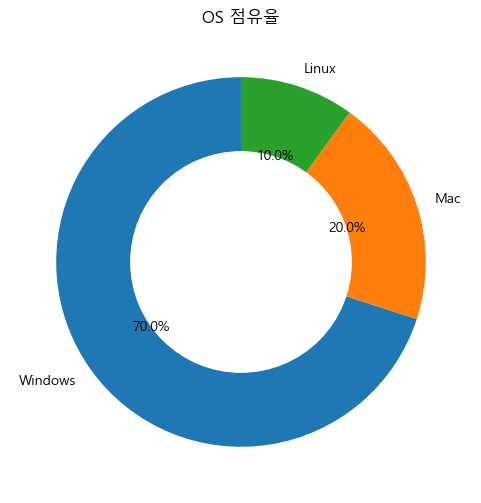

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "OS": ["Windows", "Mac", "Linux"],
    "사용자수": [70, 20, 10]
})

# 01. 한글 깨짐 방지 설정★
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 02. 그래프 크기 설정
plt.figure(figsize=(6,6))

# 03. 도넛 그래프
plt.pie(df['사용자수'],labels=df['OS'],autopct='%1.1f%%',startangle=90)

centre_circle = plt.Circle((0,0), 0.6, fc='white') # 가운데 원 그리기
plt.gca().add_artist(centre_circle) # => 그래프에 추가

# 04. 제목 
plt.title('OS 점유율')

plt.show()

#### 문제05) 3개 데이터를 부서 기준으로 병합하시오 (outer 조인)
#### 결측치는 각 컬럼의 평균값으로 처리하시오
#### 기본급과 성과급, 수당을 이용하여 누적 세로 막대그래프를 생성하시오

####  그래프 구성:
#### • 아래: 기본급
#### • 중간: 성과급 (누적)
#### • 위: 수당 (누적)
#### • 범례(legend) 추가
#### • 그래프 제목: "부서별 급여 구조"
#### • x축: 부서 / y축: 금액
#### • 그래프를 이미지로 저장 (salary_chart.png, dpi=300)
#### 아래 세개의 데이터를 병합하여 작성

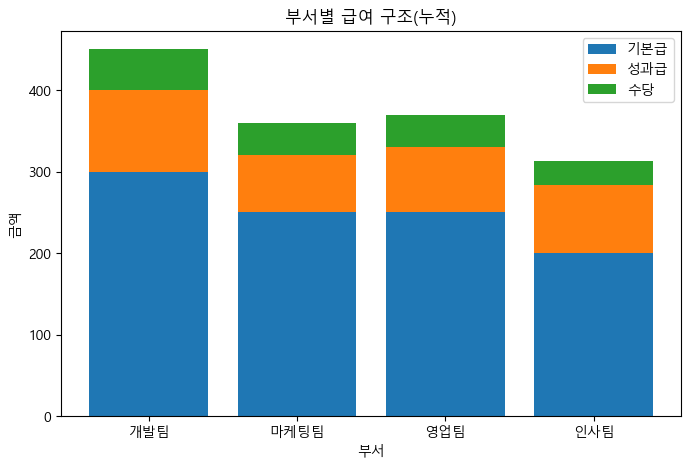

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

df1 = pd.DataFrame({
    "부서": ["개발팀", "영업팀", "인사팀"],
    "기본급": [300, 250, 200]
})

df2 = pd.DataFrame({
    "부서": ["개발팀", "영업팀", "마케팅팀"],
    "성과급": [100, 80, 70]
})

df3 = pd.DataFrame({
    "부서": ["개발팀", "영업팀", "인사팀"],
    "수당": [50, 40, 30]
})

# merge(합집합)
merged01 = pd.merge(df1, df2, on='부서', how='outer')
merged = pd.merge(merged01, df3, on='부서', how='outer')

# 결측치 처리
merged['기본급'] = merged['기본급'].fillna(merged['기본급'].mean())
merged['성과급'] = merged['성과급'].fillna(merged['성과급'].mean())
merged['수당'] = merged['수당'].fillna(merged['수당'].mean())

# 01. 한글 깨짐 방지 설정★
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 02. 그래프 크기 설정
plt.figure(figsize=(8,5))

# 03. 누적 그래프
# 첫번째 막대
plt.bar(merged['부서'],merged['기본급'],label='기본급')
# 두번째 막대
plt.bar(merged['부서'],merged['성과급'],bottom=merged['기본급'],label='성과급')
# 세번째 막대
plt.bar(merged['부서'],merged['수당'],bottom=merged['성과급']+merged['기본급'],label='수당')

# 04. 제목, 라벨 지정
plt.title('부서별 급여 구조(누적)')
plt.xlabel('부서')
plt.ylabel('금액')

# 05. 범례
plt.legend()

plt.show()
